# Detecting Equilateral Triangles

The task of detecting equilateral triangles from clusters of points is used to test our architecture.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
from tqdm import tqdm
import torch

sys.path.insert(0, str(Path("..").resolve() / "src"))
from transformers.tests.equilateral_triangles import generate_dataset
from transformers.vision_transformer import VisionTransformer
from transformers.utils import evaluate, get_image_batch, get_image_batches, make_balanced_subset, patchify_images

## Generate dataset

In [ ]:
# output_path = Path("/Users/juanfrancisco/Desktop/Transformers/data/equilateral_triangles/")
# seed = 42
# image_size = 64 # Size of the generated images (64x64 pixels)
# n_train_samples = 5000 # Total number of training samples, 50k in goyal
# n_val_samples = 1000 # Total number of validation samples, 10k in goyal

# X_train, y_train, centers_train = generate_dataset(
#     n_samples=n_train_samples,
#     image_size=image_size,
#     seed=seed)

# X_val, y_val, centers_val = generate_dataset(
#     n_samples=n_val_samples,
#     image_size=image_size,
#     seed=seed)

# print("Train images:", X_train.shape)
# print("Train labels:", y_train.shape)
# print("Validation images:", X_val.shape)
# print("Validation labels:", y_val.shape)

# print("Positive examples:", np.sum(y_train == 1))
# print("Negative examples:", np.sum(y_train == 0))

# np.save(output_path / "X_train.npy", X_train)
# np.save(output_path / "y_train.npy", y_train)
# np.save(output_path / "centers_train.npy", centers_train)

# np.save(output_path / "X_val.npy", X_val)
# np.save(output_path / "y_val.npy", y_val)
# np.save(output_path / "centers_val.npy", centers_val)

Train images: (5000, 64, 64)
Train labels: (5000,)
Validation images: (1000, 64, 64)
Validation labels: (1000,)
Positive examples: 2500
Negative examples: 2500


In [3]:
data_path = Path(str(Path("..").resolve() / "data/equilateral_triangles"))

X_train = np.load(data_path / "X_train.npy")
y_train = np.load(data_path / "y_train.npy")
centers_train = np.load(data_path / "centers_train.npy")

X_val = np.load(data_path / "X_val.npy")
y_val = np.load(data_path / "y_val.npy")
centers_val = np.load(data_path / "centers_val.npy")

print("Train images:", X_train.shape)
print("Train labels:", y_train.shape)
print("Validation images:", X_val.shape)
print("Validation labels:", y_val.shape)

print("Train positive examples:", np.sum(y_train == 1))
print("Train negative examples:", np.sum(y_train == 0))

print("Val positive examples:", np.sum(y_val == 1))
print("Val negative examples:", np.sum(y_val == 0))

Train images: (50000, 64, 64)
Train labels: (50000,)
Validation images: (10000, 64, 64)
Validation labels: (10000,)
Train positive examples: 25000
Train negative examples: 25000
Val positive examples: 5000
Val negative examples: 5000


### Plot

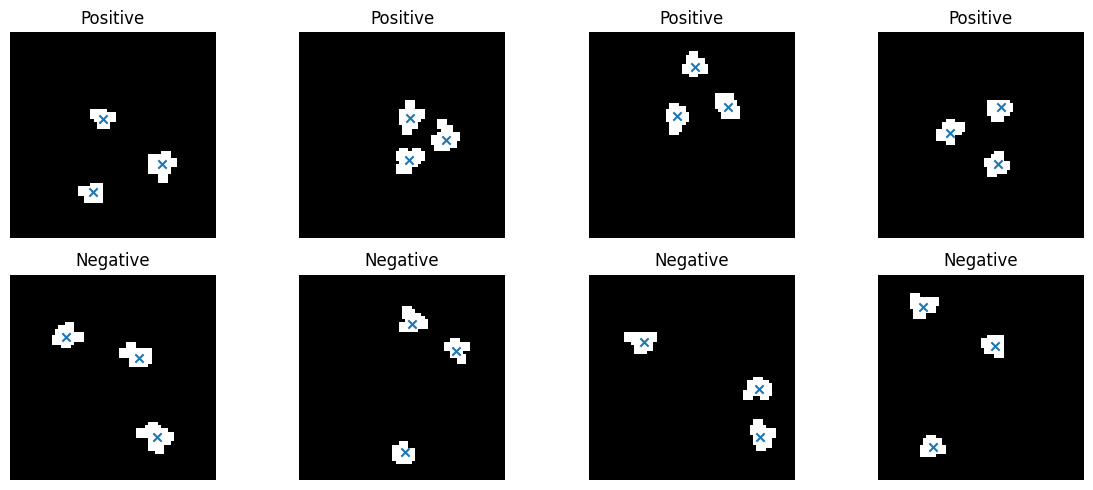

In [4]:
n_positive = 4
n_negative = 4

pos_indices = np.where(y_train == 1)[0][:n_positive]
neg_indices = np.where(y_train == 0)[0][:n_negative]

selected = list(pos_indices) + list(neg_indices)

n_total = len(selected)
fig, axes = plt.subplots(2, max(n_positive, n_negative), figsize=(12, 5))

for ax in axes.flat:
    ax.axis("off")

for plot_idx, idx in enumerate(pos_indices):
    ax = axes[0, plot_idx]
    ax.imshow(X_train[idx], cmap="gray", origin="upper")
    ax.set_title("Positive")
    ax.axis("off")

    if centers_train is not None:
        ax.scatter(centers_train[idx, :, 0], centers_train[idx, :, 1], marker="x")

for plot_idx, idx in enumerate(neg_indices):
    ax = axes[1, plot_idx]
    ax.imshow(X_train[idx], cmap="gray", origin="upper")
    ax.set_title("Negative")
    ax.axis("off")

    if centers_train is not None:
        ax.scatter(centers_train[idx, :, 0], centers_train[idx, :, 1], marker="x")

plt.tight_layout()
plt.show()

### Create batches

In [5]:
image_size = X_train.shape[1]
num_patches = 16
batch_size = 64

patched_dataset = patchify_images(X_train, num_patches=num_patches)
batch_x, batch_y = get_image_batch(patched_dataset, y_train, batch_size=batch_size)

print(f"{num_patches} patches of shape {int(np.sqrt(patched_dataset.shape[2]))}x{int(np.sqrt(patched_dataset.shape[2]))} pixels each")
print("Patched dataset shape:", patched_dataset.shape)
print("Example batch shapes:", batch_x.shape)

16 patches of shape 16x16 pixels each
Patched dataset shape: (50000, 16, 256)
Example batch shapes: torch.Size([64, 16, 256])


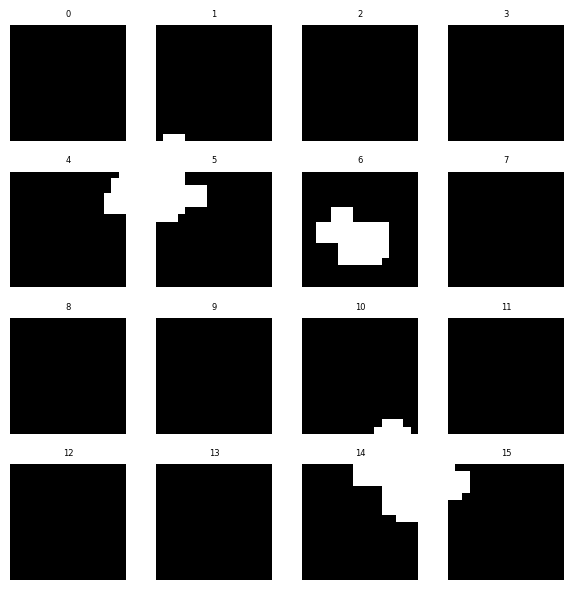

In [6]:
patch_size = int(image_size / (num_patches ** 0.5))
image_patches = patched_dataset[0]

n_patches_per_side = image_size // patch_size

assert image_patches.shape[0] == n_patches_per_side ** 2
assert image_patches.shape[1] == patch_size * patch_size

fig, axes = plt.subplots(
    n_patches_per_side,
    n_patches_per_side,
    figsize=(6, 6)
)

for patch_idx, ax in enumerate(axes.flat):
    patch = image_patches[patch_idx].reshape(patch_size, patch_size)
    ax.imshow(patch, cmap="gray", vmin=0, vmax=1)
    ax.set_title(str(patch_idx), fontsize=6)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Training

In [13]:
# hyperparameters from Goyal
emb_dim = 32   # dimension of each patch 256 for goyal
num_heads = 4   # set of Q,K,V matrices during self attention
head_size = 64 # dimension of each head during self attention q,k,v
n_layer = 4     # number of blocks

dropout = 0.2  # percentage of neurons to drop during training, helps prevent overfitting
learning_rate = 1e-4
epochs = 200
steps_per_epoch = len(patched_dataset) // batch_size

num_patches = 256 # Number of patches
patch_size = int(image_size / (num_patches ** 0.5))
batch_size = 64

In [14]:
# reduced hyperparameters
emb_dim = 32   # dimension of each patch 256 for goyal
num_heads = 4   # set of Q,K,V matrices during self attention
head_size = 64 # dimension of each head during self attention q,k,v
n_layer = 4     # number of blocks

num_patches = 64 # Number of patches
patch_size = int(image_size / (num_patches ** 0.5))
batch_size = 32
dropout = 0.2  # percentage of neurons to drop during training, helps prevent overfitting
learning_rate = 1e-4
epochs = 100

num_train_per_class = 500
num_val_per_class = 500

reduced_x_train, reduced_y_train = make_balanced_subset(
    X_train,
    y_train,
    num_per_class=num_train_per_class,
    seed=42
)

reduced_x_val, reduced_y_val = make_balanced_subset(
    X_val,
    y_val,
    num_per_class=num_val_per_class,
    seed=123
)

patched_train = patchify_images(reduced_x_train, num_patches=num_patches)
patched_val = patchify_images(reduced_x_val, num_patches=num_patches)

print("Train shape:", patched_train.shape)
print("Val shape:", patched_val.shape)

print("Train positive ratio:", reduced_y_train.mean())
print("Val positive ratio:", reduced_y_val.mean())

Train shape: (1000, 64, 64)
Val shape: (1000, 64, 64)
Train positive ratio: 0.5
Val positive ratio: 0.5


In [15]:
model = VisionTransformer(
    emb_dim=emb_dim,
    patch_size=patch_size,
    n_patches=num_patches,
    num_heads=num_heads,
    head_size=head_size,
    n_layer=n_layer,
    dropout=dropout
)

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=epochs)

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in tqdm(range(epochs)):
    model.train()

    for x_batch, y_batch in get_image_batches(
        patched_train,
        reduced_y_train,
        batch_size=batch_size,
    ):
        logits, loss = model(x_batch, y_batch)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    scheduler.step()

    train_loss, train_acc = evaluate(
        model,
        patched_train,
        reduced_y_train,
        batch_size=batch_size,
    )

    val_loss, val_acc = evaluate(
        model,
        patched_val,
        reduced_y_val,
        batch_size=batch_size
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

100%|██████████| 100/100 [01:57<00:00,  1.17s/it]


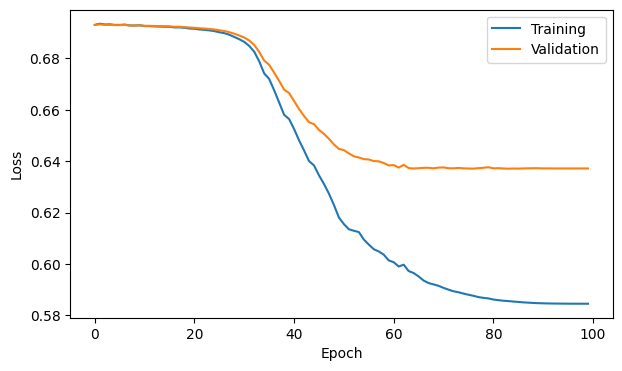

In [21]:
plt.figure(figsize=(7, 4))

plt.plot(train_losses, label="Training")
plt.plot(val_losses, label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

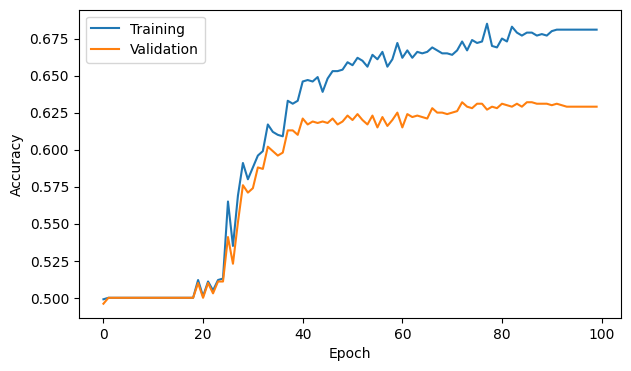

In [22]:
plt.figure(figsize=(7, 4))
plt.plot(train_accuracies, label="Training")
plt.plot(val_accuracies, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()